# Introducción a Polars

**Polars** es una biblioteca de manipulación de datos extremadamente rápida escrita en **Rust** y basada en la especificación **Apache Arrow**. A diferencia de otras herramientas, Polars ha sido diseñada desde cero para ofrecer un rendimiento óptimo en hardware moderno.

### Características principales:
- **Multiprocesamiento (Parallel by Design):** Aprovecha todos los núcleos de tu CPU de forma nativa.
- **Evaluación Diferida (Lazy Evaluation):** Optimiza las consultas antes de ejecutarlas para minimizar el uso de memoria y tiempo de CPU.
- **Zero-copy:** Gracias a Apache Arrow, minimiza la sobrecarga al mover datos entre procesos.
- **Sintaxis Expresiva:** Proporciona un lenguaje de expresiones coherente y fácil de leer.



# Series

## Importar la Biblioteca Polars


In [3]:
import polars as pl

- El atributo `__version__` muestra la versión instalada de Polars.
- La función `show_versions` devuelve las versiones de Polars, Python y otras dependencias junto con información del sistema.

In [4]:
pl.__version__

'1.35.2'

In [5]:
pl.show_versions()

--------Version info---------
Polars:              1.35.2
Index type:          UInt32
Platform:            Linux-6.6.113+-x86_64-with-glibc2.35
Python:              3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Runtime:             rt32

----Optional dependencies----
Azure CLI            <not installed>
adbc_driver_manager  <not installed>
altair               5.5.0
azure.identity       <not installed>
boto3                <not installed>
cloudpickle          3.1.2
connectorx           <not installed>
deltalake            <not installed>
fastexcel            <not installed>
fsspec               2025.3.0
gevent               <not installed>
google.auth          2.47.0
great_tables         <not installed>
matplotlib           3.10.0
numpy                2.0.2
openpyxl             3.1.5
pandas               2.2.2
polars_cloud         <not installed>
pyarrow              18.1.0
pydantic             2.12.3
pyiceberg            0.11.1
sqlalchemy           2.0.48
torch                2.1

### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/api/polars.show_versions.html

## Introducción a las Series
- Una `Series` es una columna única de datos homogéneos
- Una `Series` es una estructura de datos unidimensional.

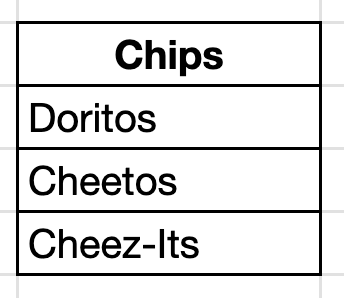

## Crear una Series
- El constructor `pl.Series` en la parte superior de Polars admite una variedad de entradas de datos.
- El parámetro `values` proporciona los datos para la `Series`.

In [6]:
pl.Series(["Doritos", "Cheetos", "Cheez-Its"])

""
str
"""Doritos"""
"""Cheetos"""
"""Cheez-Its"""


- Si pasamos los datos directamente como primer parámetro, Polars asumirá que la `Series` no tiene nombre (un antipatrón).
- El patrón recomendado es pasar un `name` como primer parámetro, y luego los datos.

In [ ]:
pl.Series("Chips", ["Doritos", "Cheetos", "Cheez-Its"])
pl.Series(name="Chips", values=["Doritos", "Cheetos", "Cheez-Its"])
pl.Series("Chips", values=["Doritos", "Cheetos", "Cheez-Its"])

Chips
str
"""Doritos"""
"""Cheetos"""
"""Cheez-Its"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/concepts/data-types-and-structures/#series

In [ ]:
# pl.Series("Chips", values=["Doritos", "Cheetos", "Cheez-Its", 6])

## Inferencia de Tipo de Dato
- Polars inferirá el tipo de dato de la `Series` a partir de los valores proporcionados.
- El parámetro `dtype` establece el tipo de dato de los valores de la `Series`. Úsalo para sobrescribir la inferencia de tipo predeterminada de Polars.
- Polars puede abreviar el tipo de dato (por ejemplo, `pl.Float64` será `f64` y `pl.String` será `str`).

In [8]:
pl.Series("Prices", [1.99, 2.99, 3.49])
# pl.Series("Prices", [1.99, 2.99, 3.49], pl.Float64)
# pl.Series("Prices", [1.99, 2.99, 3.49], dtype=pl.Float64)

Prices
f64
1.99
2.99
3.49


- `Float64` (64 bits/8 bytes) y `Float32` (32 bits/4 bytes) son ambos tipos de punto flotante (decimal).
- Un `f64` ofrece mayor precisión (15-17 dígitos significativos) que un `f32` (7 dígitos significativos), pero ocupa el doble de memoria.
- Dígitos Significativos: el total de dígitos (antes y después del punto) que son confiables.
- Prioriza la simplicidad del código y el valor de negocio antes de optimizar la eficiencia.

In [9]:
pl.Series("Prices", [1.99, 2.99, 3.49], pl.Float32)

Prices
f32
1.99
2.99
3.49


- Polars lanzará un error si el tipo de dato de los valores no coincide con el argumento `dtype`.

In [11]:
# pl.Series("Prices", [1.99, 2.99, 3.49], dtype=pl.String)

- Establece el parámetro `strict` en `False` para forzar/convertir los tipos de datos al `dtype` especificado.

In [ ]:
pl.Series("Prices", [1.99, 2.99, 3.49], dtype=pl.String, strict=False)
# pl.Series("Prices", [1.99, 2.99, 3.49, "4.49"], dtype=pl.String, strict=False)
# pl.Series("Prices", [1.99, 2.99, 3.49, "4.49"], dtype=pl.Float64, strict=False)
# pl.Series("Prices", [1.99, 2.99, 3.49, "nonsense"], dtype=pl.Float64, strict=False)

Prices
f64
1.99
2.99
3.49
null


### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/series/index.html
- **https://docs.pola.rs/api/python/stable/reference/datatypes.html**

## Atributos
- Un **atributo** es una pieza de información sobre un objeto.
- Para acceder al valor de un atributo, escribe el objeto, luego un punto y el nombre del atributo.
- El atributo `name` proporciona el nombre de la `Series`.
- El atributo `dtype` proporciona el tipo de dato de la `Series`.
- El atributo `shape` proporciona una tupla con las dimensiones (ancho x alto) de una estructura de datos de Polars.

In [12]:
chips = pl.Series("Chips", ["Doritos", "Cheetos", "Cheez-Its"])
chips

Chips
str
"""Doritos"""
"""Cheetos"""
"""Cheez-Its"""


In [13]:
chips.name

'Chips'

In [14]:
chips.dtype

String

In [15]:
chips.shape

(3,)

### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.name.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.dtype.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.shape.html

## Valores Faltantes

- Polars marca las entradas faltantes en una `Series` con un valor `null`.
- El tipo `None` de Python representa la ausencia de un valor.
- Polars convertirá un `None` en una lista de Python a un valor `null`/faltante.

In [16]:
temps = pl.Series("Temperatures", [0.0, 85.3, 87.3, None, 92.4])
temps

Temperatures
f64
0.0
85.3
87.3
null
92.4


- Polars admite operaciones matemáticas en `Series`.
- Podemos sumar, restar, multiplicar, dividir, etc. cada valor de la `Series` con un valor constante.
- Para cada operación matemática, Polars devuelve una nueva `Series` con los nuevos valores.
- La mayoría de las operaciones sobre valores `null` producen valores `null`.
- El símbolo `+` suma un valor escalar a cada valor de fila.

In [17]:
temps + 5.5

Temperatures
f64
5.5
90.8
92.8
null
97.9


- Polars devolverá un valor `NaN` (no es un número) para operaciones numéricas inválidas.
- Un ejemplo de operación inválida es dividir 0 entre 0.
- `NaN` es un valor diferente de `null`.

In [18]:
temps / 0

Temperatures
f64
NaN
inf
inf
null
inf


- Polars considera `NaN` como algo claramente separado de `null`.
- Un `NaN` es un valor de tipo flotante (`f64`).

### Puntos Clave:
- **`null`**: Es la ausencia de datos (celda vacía).
- **`NaN`**: Es un valor numérico inválido (Error matemático).
- **`Inf`**: Es un valor numérico que tiende al infinito.

En Polars, `null_count()` no contará los `NaN` ni los `Inf`, ya que técnicamente contienen un valor de punto flotante.

### Lectura Adicional
- https://docs.pola.rs/user-guide/expressions/missing-data/#null-and-nan-values
- https://docs.pola.rs/user-guide/expressions/missing-data/#not-a-number-or-nan-values

## El Método `alias`

- Un **método** es una función asociada a un objeto.
- El método `alias` devuelve una nueva `Series` con un nuevo nombre.

In [19]:
chips = pl.Series("Chips", ["Doritos", "Cheetos", "Cheez-Its"])
chips

Chips
str
"""Doritos"""
"""Cheetos"""
"""Cheez-Its"""


In [20]:
chips.alias("Snacks")

Snacks
str
"""Doritos"""
"""Cheetos"""
"""Cheez-Its"""


- El método `alias` devuelve una copia de la `Series`. La `Series` original no se ve afectada.
- Reasigna el valor de retorno de un método a una variable para sobrescribir el valor original de la variable.
- **Los métodos de Polars normalmente devuelven un nuevo objeto/copia**.

In [21]:
chips = chips.alias("Snacks")

In [ ]:
chips

Snacks
str
"""Doritos"""
"""Cheetos"""
"""Cheez-Its"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/expressions/expression-expansion/#renaming-a-single-column-with-alias
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.alias.html

## Importar un Archivo CSV

- El formato de valores separados por comas (CSV) almacena un registro por fila.
- El formato CSV separa los valores de cada fila con comas.

```
name,strength,magic,speed
Zorblax,9,2,5
Mira,4,9,8
Thud,10,1,2
Eloria,3,10,7
```

- La función `read_csv` importa un archivo de valores separados por comas (CSV).
- La función `read_csv` devuelve un `DataFrame`, una tabla que contiene 1 o más `Series`.
- Observa que la salida `shape` incluye el número de filas y el número de columnas.
- Los guiones bajos en `1_000` son para mejorar la legibilidad.

In [22]:
# (print work directory) Para verificar el directorio activo en el entorno de ejecución
# !pwd

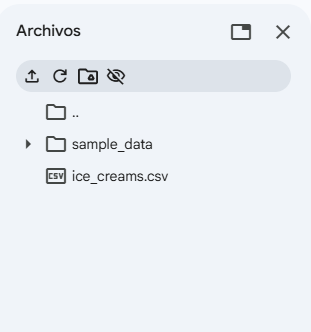

In [ ]:
ice_creams = pl.read_csv("/content/ice_creams.csv")
ice_creams

ice_cream_flavor
str
"""Cherry Chip Drizzle"""
"""Mango Marshmallow Magic"""
"""Vanilla Sprinkle Storm"""
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
…
"""Mango Fudge Rush"""
"""Honey Fudge Surprise"""
"""Cinnamon Cookie Bliss"""


In [ ]:
type(ice_creams)

polars.dataframe.frame.DataFrame

- El método `to_series` convierte una columna de un `DataFrame` en una `Series`.
- Con un `DataFrame` de 1 columna, Polars asume que debe usar la única columna disponible.
- Si un `DataFrame` tiene múltiples columnas, debemos proporcionar el índice numérico de la columna.
- Polars asigna a las columnas un índice (posición en la fila) comenzando desde 0.

In [ ]:
ice_creams.to_series()
# ice_creams.to_series(0)

ice_cream_flavor
str
"""Cherry Chip Drizzle"""
"""Mango Marshmallow Magic"""
"""Vanilla Sprinkle Storm"""
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
…
"""Mango Fudge Rush"""
"""Honey Fudge Surprise"""
"""Cinnamon Cookie Bliss"""


- El encadenamiento de métodos invoca un método sobre el valor de retorno de una invocación de método anterior.

In [ ]:
ice_creams = pl.read_csv("ice_creams.csv").to_series()
ice_creams

ice_cream_flavor
str
"""Cherry Chip Drizzle"""
"""Mango Marshmallow Magic"""
"""Vanilla Sprinkle Storm"""
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
…
"""Mango Fudge Rush"""
"""Honey Fudge Surprise"""
"""Cinnamon Cookie Bliss"""


### Lectura Adicional
- https://docs.pola.rs/user-guide/io/csv/#read-write
- https://docs.pola.rs/api/python/stable/reference/api/polars.read_csv.html

## Los Métodos head y tail
- El método `head` devuelve filas desde el inicio/principio de la `Series`.
- El método `tail` devuelve filas desde el final de la `Series`.
- Por defecto, ambos métodos devuelven 10 filas. Puedes pasar un número personalizado de filas a devolver.

In [ ]:
ice_creams = pl.read_csv("ice_creams.csv").to_series()
ice_creams

ice_cream_flavor
str
"""Cherry Chip Drizzle"""
"""Mango Marshmallow Magic"""
"""Vanilla Sprinkle Storm"""
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
…
"""Mango Fudge Rush"""
"""Honey Fudge Surprise"""
"""Cinnamon Cookie Bliss"""


In [ ]:
ice_creams.head()

ice_cream_flavor
str
"""Cherry Chip Drizzle"""
"""Mango Marshmallow Magic"""
"""Vanilla Sprinkle Storm"""
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
"""Pistachio Butter Crave"""
"""Espresso Brownie Rush"""
"""Peach Flake Storm"""
"""Coconut Flake Delight"""


In [ ]:
# ice_creams.head(3)
ice_creams.head(n=7)

ice_cream_flavor
str
"""Cherry Chip Drizzle"""
"""Mango Marshmallow Magic"""
"""Vanilla Sprinkle Storm"""
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
"""Pistachio Butter Crave"""
"""Espresso Brownie Rush"""


- El método `limit` es un alias del método `head`.

In [ ]:
ice_creams.limit(7)

ice_cream_flavor
str
"""Cherry Chip Drizzle"""
"""Mango Marshmallow Magic"""
"""Vanilla Sprinkle Storm"""
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
"""Pistachio Butter Crave"""
"""Espresso Brownie Rush"""


In [ ]:
ice_creams.tail(3)
ice_creams.tail(n=4)

ice_cream_flavor
str
"""Honey Fudge Surprise"""
"""Cinnamon Cookie Bliss"""
"""Coconut Fudge Twist"""
"""Cinnamon Crumb Magic"""


- Un valor negativo devuelve todas las filas desde el inicio _excepto_ el número especificado de filas a excluir desde el final.
- Por ejemplo, `head(-3)` devuelve todas las filas excepto las últimas 3.

In [ ]:
ice_creams.head(-3)

ice_cream_flavor
str
"""Cherry Chip Drizzle"""
"""Mango Marshmallow Magic"""
"""Vanilla Sprinkle Storm"""
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
…
"""Vanilla Swirl Delight"""
"""Chocolate Graham Blizzard"""
"""Honey Caramel Delight"""


- Con un valor negativo, el método `tail` devuelve todas las filas desde el final excepto el número especificado de filas a excluir.
- Por ejemplo, `tail(-3)` devuelve todas las filas excepto las primeras 3.

In [ ]:
ice_creams.tail(-3)

ice_cream_flavor
str
"""Blueberry Flake Delight"""
"""Vanilla Chunk Crave"""
"""Pistachio Butter Crave"""
"""Espresso Brownie Rush"""
"""Peach Flake Storm"""
…
"""Mango Fudge Rush"""
"""Honey Fudge Surprise"""
"""Cinnamon Cookie Bliss"""


- Los métodos `first` y `last` devuelven el primer y último valor de la `Series`.

In [ ]:
ice_creams.first()

'Cherry Chip Drizzle'

In [ ]:
ice_creams.last()

'Cinnamon Crumb Magic'

### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.head.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.tail.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.limit.html

## Optimización de Memoria y el Parámetro `schema_overrides`
- Polars infiere el tipo de dato de una columna a partir de sus valores. Por defecto usa `i64` (entero de 64 bits) para números enteros.

In [ ]:
daily_steps = pl.read_csv("daily_steps.csv").to_series()
daily_steps.head(5)

daily_steps
i64
6030
12448
13482
8486
6381


- El método `estimated_size` devuelve el tamaño en memoria de la `Series` en bytes.
- La mayoría de las computadoras asignan 8 bits a 1 byte. 64 bits por entero equivalen a 8 bytes.
- La `Series` tiene 1000 filas de enteros.
- 1000 enteros * 8 bytes por entero = 8000 bytes.
- Un `i64` soporta valores desde -9,223,372,036,854,775,808 hasta 9,223,372,036,854,775,807 (-9 trillones a 9 trillones).

In [ ]:
daily_steps.estimated_size()

8000

In [ ]:
daily_steps.min()
daily_steps.max()

24930

- El parámetro `schema_overrides` acepta un diccionario para sobrescribir el tipo inferido.
- Agrega un par clave-valor por cada columna a sobrescribir. Usa el nombre de la columna como clave y el tipo deseado como valor.

In [ ]:
daily_steps = pl.read_csv(
    "daily_steps.csv", schema_overrides={"daily_steps": pl.Int16}
).to_series()
daily_steps.head(5)

daily_steps
i16
6030
12448
13482
8486
6381


- Un `Int16` soporta valores desde -32,768 hasta 32,767.
- Si el conjunto de datos tiene un valor mayor a 32,767, la importación generará un error.
- La `Series` aún tiene 1000 filas, pero cada entero ocupa 16 bits (2 bytes).
- 1000 enteros * 2 bytes por entero = 2000 bytes (una cuarta parte del original).

In [ ]:
daily_steps.estimated_size()

2000

- No podemos dar pasos negativos en un día, por lo que un tipo entero sin signo (0 o positivo) es ideal.
- Los enteros sin signo no soportan valores negativos, pero se extienden el doble en la dirección positiva.
- Un `UInt16` soporta valores desde 0 hasta 65,535.

In [ ]:
daily_steps = pl.read_csv(
    "daily_steps.csv", schema_overrides={"daily_steps": pl.UInt16}
).to_series()
daily_steps.head(5)

daily_steps
u16
6030
12448
13482
8486
6381


- El tamaño se mantiene igual (1000 enteros x 2 bytes por entero).

In [ ]:
daily_steps.estimated_size()

2000

## Ordenar una `Series`
- El método `sort` ordena los valores de una `Series`.
- Un orden ascendente ordena de menor a mayor (alfabéticamente para cadenas de texto).
- Un orden descendente ordena de mayor a menor (alfabéticamente inverso para cadenas de texto).
- El parámetro `descending` establece el orden. Su argumento predeterminado es `False` (orden ascendente).

In [ ]:
ice_creams = pl.read_csv("ice_creams.csv").to_series()

daily_steps = pl.read_csv(
    "daily_steps.csv", schema_overrides={"daily_steps": pl.UInt16}
).to_series()

In [ ]:
daily_steps.sort()
# daily_steps.sort(descending=False)
# daily_steps.sort(descending=True)

daily_steps
u16
24930
24920
24870
24804
24770
…
5037
5028
5022


In [ ]:
ice_creams.sort() #Ascending by default
ice_creams.sort(descending=False)
ice_creams.sort(descending=True)

ice_cream_flavor
str
"""Vanilla Toffee Drizzle"""
"""Vanilla Toffee Crave"""
"""Vanilla Swirl Delight"""
"""Vanilla Swirl Bliss"""
"""Vanilla Sprinkle Storm"""
…
"""Almond Brownie Wave"""
"""Almond Brownie Storm"""
"""Almond Bits Wave"""


- Polars ordena las letras mayúsculas antes que las minúsculas.

In [ ]:
pl.Series(name="text", values=["B", "A", "b"]).sort()

text
str
"""A"""
"""B"""
"""b"""


- El método `sort` devuelve una nueva `Series` ordenada. La `Series` original no se modifica.
- **El parámetro `in_place` del método `sort` modifica la `Series` original.**
- Este parámetro es relativamente poco común; Polars generalmente devuelve una copia de la estructura de datos.

In [ ]:
ice_creams.sort(in_place=True)

ice_cream_flavor
str
"""Almond Bits Charm"""
"""Almond Bits Surprise"""
"""Almond Bits Wave"""
"""Almond Brownie Storm"""
"""Almond Brownie Wave"""
…
"""Vanilla Sprinkle Storm"""
"""Vanilla Swirl Bliss"""
"""Vanilla Swirl Delight"""


In [ ]:
ice_creams

ice_cream_flavor
str
"""Almond Bits Charm"""
"""Almond Bits Surprise"""
"""Almond Bits Wave"""
"""Almond Brownie Storm"""
"""Almond Brownie Wave"""
…
"""Vanilla Sprinkle Storm"""
"""Vanilla Swirl Bliss"""
"""Vanilla Swirl Delight"""


### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.sort.html

## Métodos Matemáticos

- El método `len` devuelve la longitud de la `Series` (el número de filas). Polars incluirá los valores `null`.
- El método `count` cuenta el número de valores no nulos.

In [ ]:
sugars = pl.read_csv("sugars.csv").to_series()
sugars

Sugars
f64
3.456
8.0
6.872
5.513
null
8.0


In [ ]:
sugars.len()

6

In [ ]:
sugars.count()

5

- El método `null_count` cuenta el número de valores nulos/faltantes en la `Series`.
- Polars excluirá los valores `NaN` del conteo en el método `null_count`.

In [ ]:
sugars.null_count()

1

- Una `Series` admite muchas operaciones estadísticas comunes.
- El método `sum` suma los valores de la `Series`.
- El método `mean` calcula el promedio de los valores de la `Series`.
- El método `product` multiplica los valores de la `Series`.
- El método `max` identifica el valor más grande de la `Series`.
- El método `min` identifica el valor más pequeño de la `Series`.
- El método `median` identifica el punto medio/valor central de una `Series` ordenada.

In [ ]:
sugars.sum()

31.841

In [ ]:
sugars.mean()

6.3682

In [ ]:
sugars.product()

8379.630157824

In [ ]:
sugars.max()

8.0

In [ ]:
sugars.min()

3.456

In [ ]:
sugars.median()

6.872

- El método `mode` devuelve una `Series` con el/los valor(es) más frecuente(s). Contendrá uno o más valores.
- El método `std` devuelve la desviación estándar de la `Series` (la desviación respecto a la media).

In [ ]:
sugars.mode()

Sugars
f64
8.0


In [ ]:
sugars.std()

1.9229945917760662

- El método `describe` devuelve un `DataFrame` con varias estadísticas.

In [ ]:
sugars.describe()
# sugars.describe().to_series(0)
# sugars.describe().to_series(1)

value
f64
5.0
1.0
6.3682
1.922995
3.456
5.513
6.872
8.0
8.0


### Lectura Adicional
- https://docs.pola.rs/user-guide/expressions/missing-data/#missing-data-metadata
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.len.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.count.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.null_count.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.sum.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.mode.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.median.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.product.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.std.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.describe.html

## Métodos de Redondeo
- El método `ceil` redondea hacia arriba al siguiente número entero.
- El método `floor` redondea hacia abajo al siguiente número entero.
- El método `round` redondea al número entero más cercano.
- Polars redondea hacia arriba los valores >= .5 y hacia abajo los valores < .5.

In [ ]:
sugars = pl.read_csv("sugars.csv").to_series()
sugars

Sugars
f64
3.456
8.0
6.872
5.513
null
8.0


In [ ]:
sugars.ceil()

Sugars
f64
4.0
8.0
7.0
6.0
null
8.0


In [ ]:
sugars.floor()

Sugars
f64
3.0
8.0
6.0
5.0
null
8.0


In [ ]:
sugars.round()

Sugars
f64
3.0
8.0
7.0
6.0
null
8.0


- Pasa al parámetro `decimals` la precisión a la que deseas redondear.
- Por ejemplo, `3.456` con una precisión de 2 se redondeará a `3.46`.

In [ ]:
sugars.round(2)

Sugars
f64
3.46
8.0
6.87
5.51
null
8.0


### Lectura Adicional
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.ceil.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.floor.html
- https://docs.pola.rs/api/python/stable/reference/series/api/polars.Series.round.html

### Lectura Adicional - Pandas vs Polars
- https://docs.pola.rs/user-guide/migration/pandas/#differences-in-concepts-between-polars-and-pandas
- https://docs.pola.rs/user-guide/misc/comparison/#pandas
- https://docs.pola.rs/user-guide/concepts/data-types-and-structures/#appendix-full-data-types-table
- https://pandas.pydata.org/docs/